In [3]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import stats
import json
import os
import sys
from cnn_model_yin import CNN, cross_validate, train

# Load data processor
sys.path.append(os.path.abspath('..'))
from data_cleanup import DataProcessor

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-paper')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (10, 6)

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print('Environment setup complete')

Environment setup complete


## 1. Data Distribution Analysis

In [4]:
# Load and prepare data
INPUT_STEPS = 24 * 3  # 72 hours
OUTPUT_STEPS = 24  # 24 hours
processor = DataProcessor(input_steps=INPUT_STEPS, output_steps=OUTPUT_STEPS, 
                         local_raw_path='../raw-consumption-data.zip')
(X_train, y_train), (X_val, y_val), (X_test, y_test) = processor.load_and_process_data()

# Select sub-metering channels
channel_indices = [4, 5, 6, 7]
channel_names = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Sub_metering_rest']
X_train_ch = X_train[:, :, channel_indices]
X_val_ch = X_val[:, :, channel_indices]
X_test_ch = X_test[:, :, channel_indices]

print(f'Data loaded: Train={X_train_ch.shape}, Val={X_val_ch.shape}, Test={X_test_ch.shape}')

Step 1/5: Fetching, cleaning, and engineering features...


e:\ywc_college\junior1\notebook\Machine Learning\pj\ECS171G13\data_cleanup.py:132: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
e:\ywc_college\junior1\notebook\Machine Learning\pj\ECS171G13\data_cleanup.py:172: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').agg(agg_dict)


Step 2/5: Resampling data to hourly and setting 'Global_active_power' as target...
Step 3/5: Splitting data and applying scaler...
Step 4/5: Creating time-series windows...
Step 5/5: Data processing complete.
Data loaded: Train=(25832, 72, 4), Val=(3529, 72, 4), Test=(4943, 72, 4)
Step 3/5: Splitting data and applying scaler...
Step 4/5: Creating time-series windows...
Step 5/5: Data processing complete.
Data loaded: Train=(25832, 72, 4), Val=(3529, 72, 4), Test=(4943, 72, 4)


e:\ywc_college\junior1\notebook\Machine Learning\pj\ECS171G13\data_cleanup.py:173: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hourly = df_hourly.fillna(method='ffill')


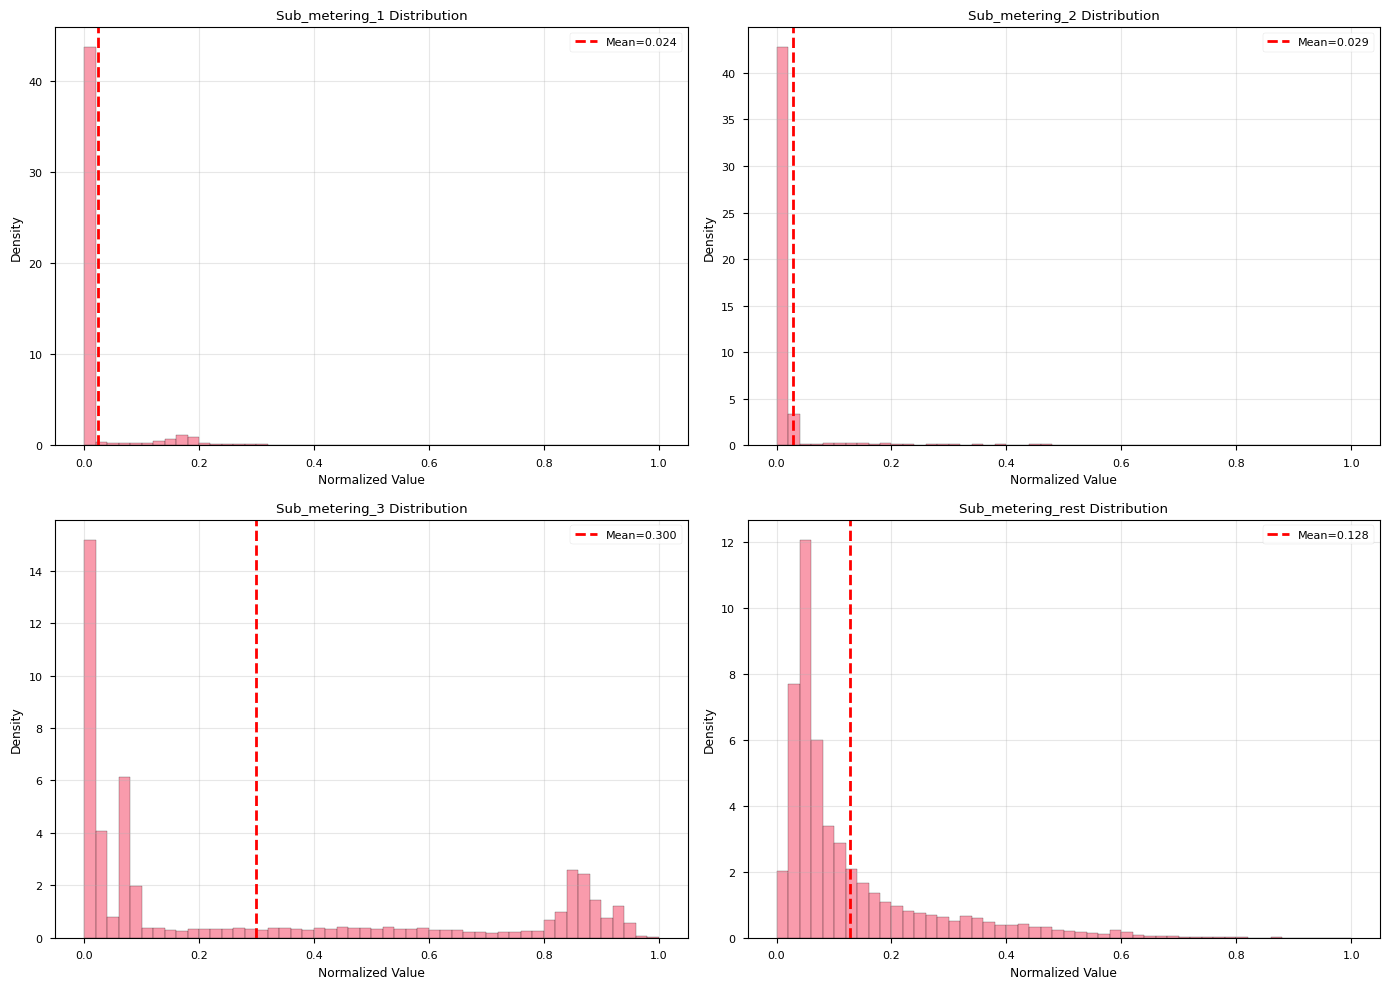

Figure 1: Feature distribution saved


In [5]:
# Plot 1: Distribution of input features across channels
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (ch_name, ax) in enumerate(zip(channel_names, axes)):
    data = X_train_ch[:, :, i].flatten()
    ax.hist(data, bins=50, alpha=0.7, edgecolor='black', density=True)
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Density')
    ax.set_title(f'{ch_name} Distribution')
    ax.grid(True, alpha=0.3)
    
    # Add statistics
    mean_val = np.mean(data)
    std_val = np.std(data)
    ax.axvline(mean_val, color='r', linestyle='--', linewidth=2, label=f'Mean={mean_val:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('fig1_feature_distribution.png', bbox_inches='tight')
plt.show()

print('Figure 1: Feature distribution saved')

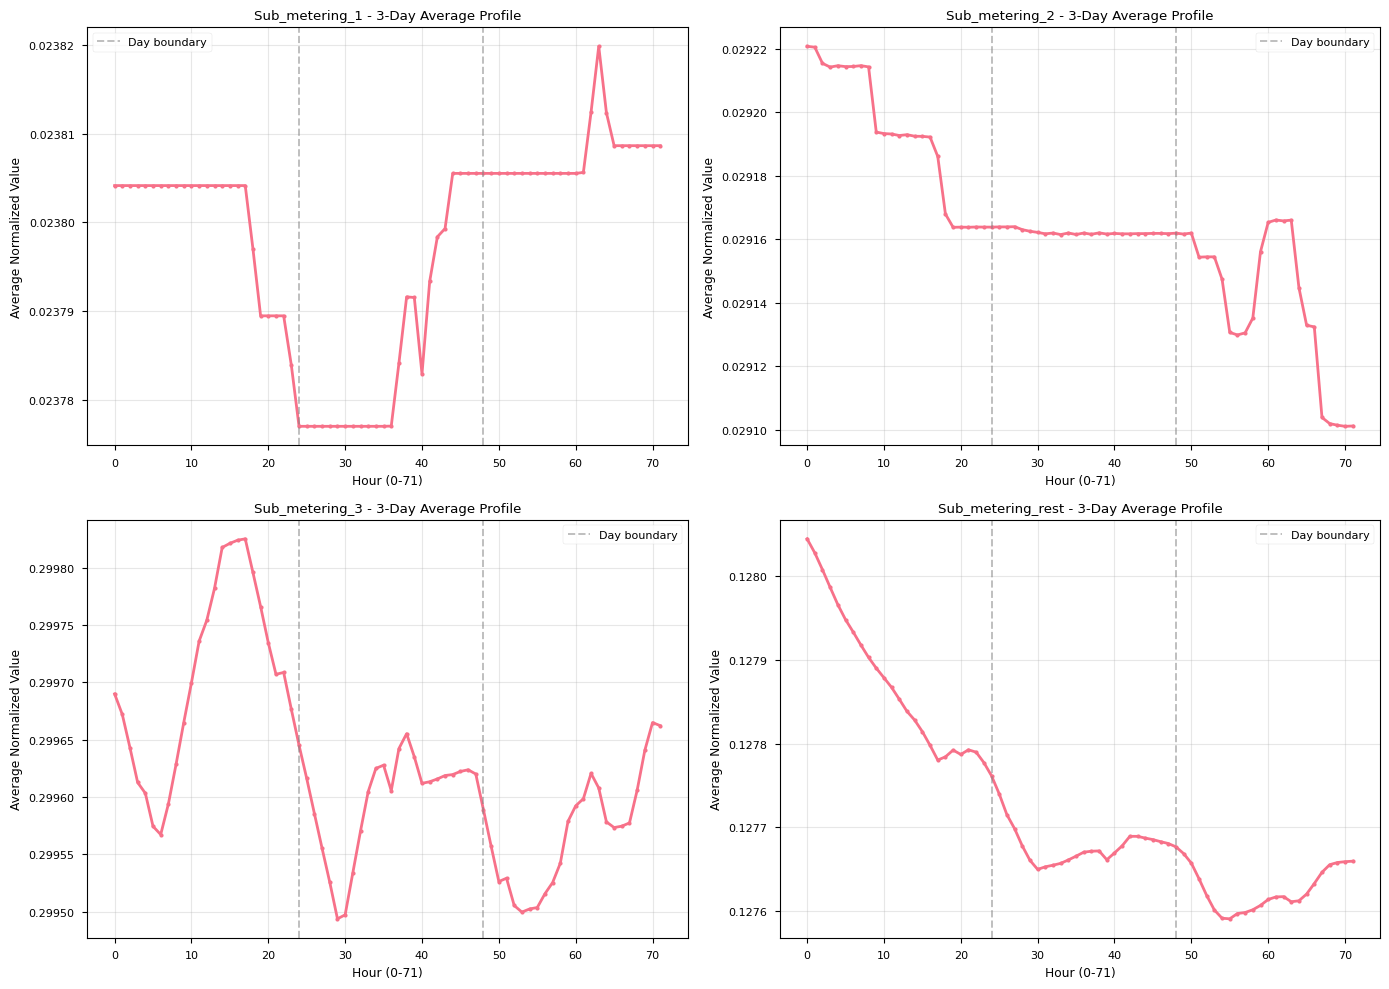

Figure 2: Temporal patterns saved


In [6]:
# Plot 2: Temporal patterns - average daily profile
# Compute average profile for each channel
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (ch_name, ax) in enumerate(zip(channel_names, axes)):
    # Average across all samples and reshape to hourly
    avg_profile = X_train_ch[:, :, i].mean(axis=0)
    ax.plot(range(len(avg_profile)), avg_profile, linewidth=2, marker='o', markersize=3)
    ax.set_xlabel('Hour (0-71)')
    ax.set_ylabel('Average Normalized Value')
    ax.set_title(f'{ch_name} - 3-Day Average Profile')
    ax.grid(True, alpha=0.3)
    ax.axvline(24, color='gray', linestyle='--', alpha=0.5, label='Day boundary')
    ax.axvline(48, color='gray', linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.savefig('fig2_temporal_patterns.png', bbox_inches='tight')
plt.show()

print('Figure 2: Temporal patterns saved')

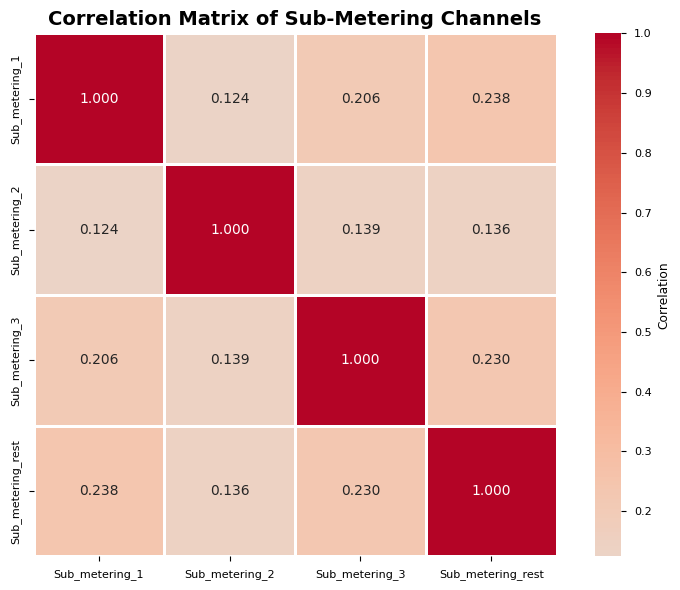

Figure 3: Correlation heatmap saved


In [7]:
# Plot 3: Correlation heatmap between channels
# Flatten data for correlation analysis
X_flat = X_train_ch.reshape(-1, 4)
corr_matrix = np.corrcoef(X_flat.T)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=channel_names, yticklabels=channel_names,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Sub-Metering Channels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Figure 3: Correlation heatmap saved')

## 2. Model Architecture Visualization

In [8]:
# Create model instance for visualization
model = CNN(in_channels=4, input_length=INPUT_STEPS, output_steps=OUTPUT_STEPS)

# Print model architecture
print('='*60)
print('CNN Model Architecture')
print('='*60)
print(model)
print('='*60)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Layer-wise parameter breakdown
print('\nLayer-wise parameter count:')
for name, param in model.named_parameters():
    print(f'{name:30s}: {param.numel():>10,} parameters, shape={list(param.shape)}')

CNN Model Architecture
CNN(
  (feature_extractor): Sequential(
    (0): Conv1d(4, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=24, bias=True)
)

Total parameters: 332,664
Trainable parameters: 332,664

Layer-wise parameter count:
feature_extractor.0.weight    :        384 parameters, shape=[32, 4, 3]
feature_extractor.0.bias      :         32 parameters, shape=[32]
feature_extractor.3.weight    :      6,144 parameters, shape=[64, 32, 3]
fea

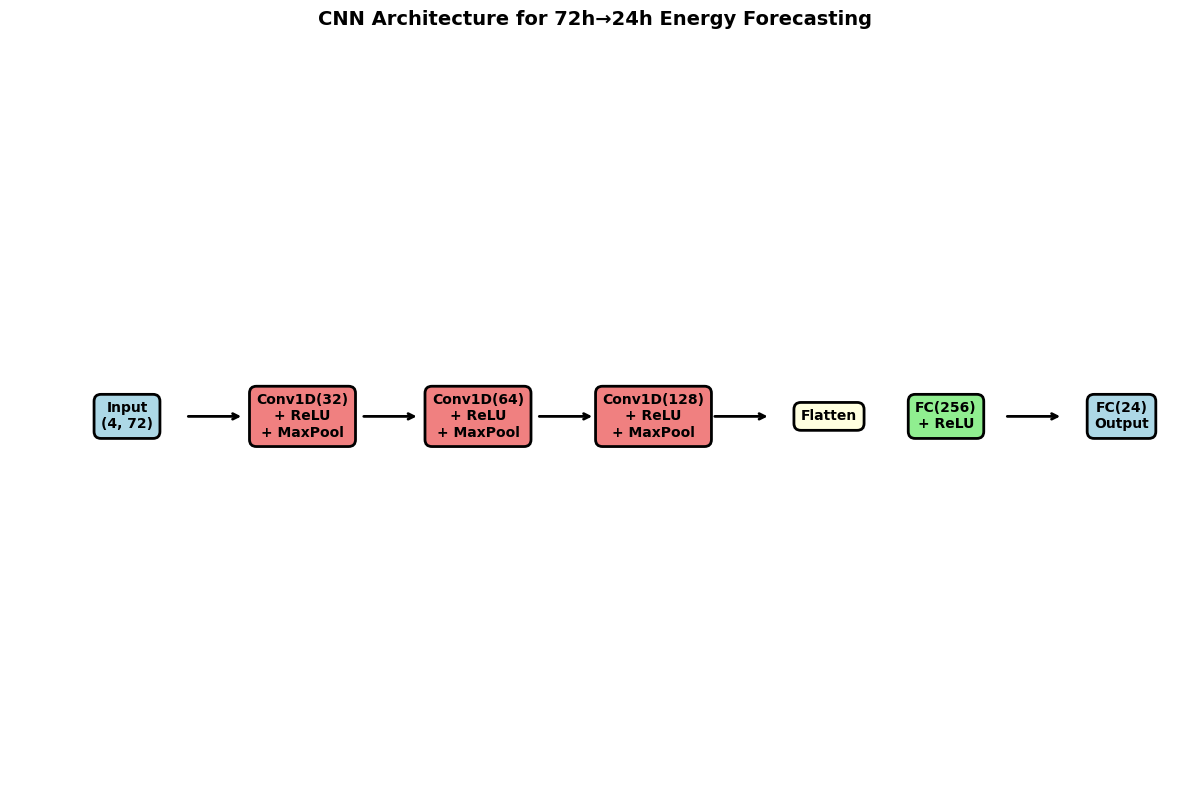

Figure 4: Model architecture diagram saved


In [9]:
# Plot 4: Model architecture diagram (simplified visualization)
fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# Define layer positions
layers = [
    ('Input\n(4, 72)', 0.1, 0.5, 'lightblue'),
    ('Conv1D(32)\n+ ReLU\n+ MaxPool', 0.25, 0.5, 'lightcoral'),
    ('Conv1D(64)\n+ ReLU\n+ MaxPool', 0.4, 0.5, 'lightcoral'),
    ('Conv1D(128)\n+ ReLU\n+ MaxPool', 0.55, 0.5, 'lightcoral'),
    ('Flatten', 0.7, 0.5, 'lightyellow'),
    ('FC(256)\n+ ReLU', 0.8, 0.5, 'lightgreen'),
    ('FC(24)\nOutput', 0.95, 0.5, 'lightblue')
]

for i, (label, x, y, color) in enumerate(layers):
    bbox = dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor='black', linewidth=2)
    ax.text(x, y, label, ha='center', va='center', fontsize=10, fontweight='bold', bbox=bbox)
    if i < len(layers) - 1:
        ax.annotate('', xy=(layers[i+1][1]-0.05, layers[i+1][2]), 
                   xytext=(x+0.05, y),
                   arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('CNN Architecture for 72h→24h Energy Forecasting', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig4_model_architecture.png', bbox_inches='tight')
plt.show()

print('Figure 4: Model architecture diagram saved')

## 3. Training Dynamics and Cross-Validation

In [10]:
# Load or train models
def make_model():
    return CNN(in_channels=4, input_length=INPUT_STEPS, output_steps=OUTPUT_STEPS)

# Create CV folds
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)
folds = []
for train_idx, val_idx in tscv.split(X_train_ch):
    Xtr = X_train_ch[train_idx]
    ytr = y_train[train_idx]
    Xval = X_train_ch[val_idx]
    yval = y_train[val_idx]
    folds.append(((Xtr, ytr), (Xval, yval)))

print(f'Created {len(folds)} CV folds')

# Train with cross-validation
EPOCHS = 30
cv_histories, cv_val_losses, cv_best_checkpoint = cross_validate(
    make_model,
    folds,
    device=None,
    epochs=EPOCHS,
    batch_size=32,
    lr=1e-3,
    verbose=True,
    checkpoint_dir='checkpoint/final_cv',
    save_best_only=True
)

print(f'CV completed. Best checkpoint: {cv_best_checkpoint}')
print(f'Final val losses per fold: {cv_val_losses}')

Created 5 CV folds
Starting fold 1/5: train (4307, 72, 4) | val (4305, 72, 4)
Epoch 1/30 - train_loss: 0.028720 - val_loss: 0.020454
Epoch 1/30 - train_loss: 0.028720 - val_loss: 0.020454
Epoch 2/30 - train_loss: 0.026253 - val_loss: 0.019183
Epoch 2/30 - train_loss: 0.026253 - val_loss: 0.019183
Epoch 3/30 - train_loss: 0.023759 - val_loss: 0.016234
Epoch 3/30 - train_loss: 0.023759 - val_loss: 0.016234
Epoch 4/30 - train_loss: 0.021106 - val_loss: 0.015226
Epoch 4/30 - train_loss: 0.021106 - val_loss: 0.015226
Epoch 5/30 - train_loss: 0.019478 - val_loss: 0.014808
Epoch 5/30 - train_loss: 0.019478 - val_loss: 0.014808
Epoch 6/30 - train_loss: 0.018627 - val_loss: 0.014567
Epoch 6/30 - train_loss: 0.018627 - val_loss: 0.014567
Epoch 7/30 - train_loss: 0.017803 - val_loss: 0.014410
Epoch 7/30 - train_loss: 0.017803 - val_loss: 0.014410
Epoch 8/30 - train_loss: 0.017256 - val_loss: 0.014280
Epoch 8/30 - train_loss: 0.017256 - val_loss: 0.014280
Epoch 9/30 - train_loss: 0.016634 - val_lo

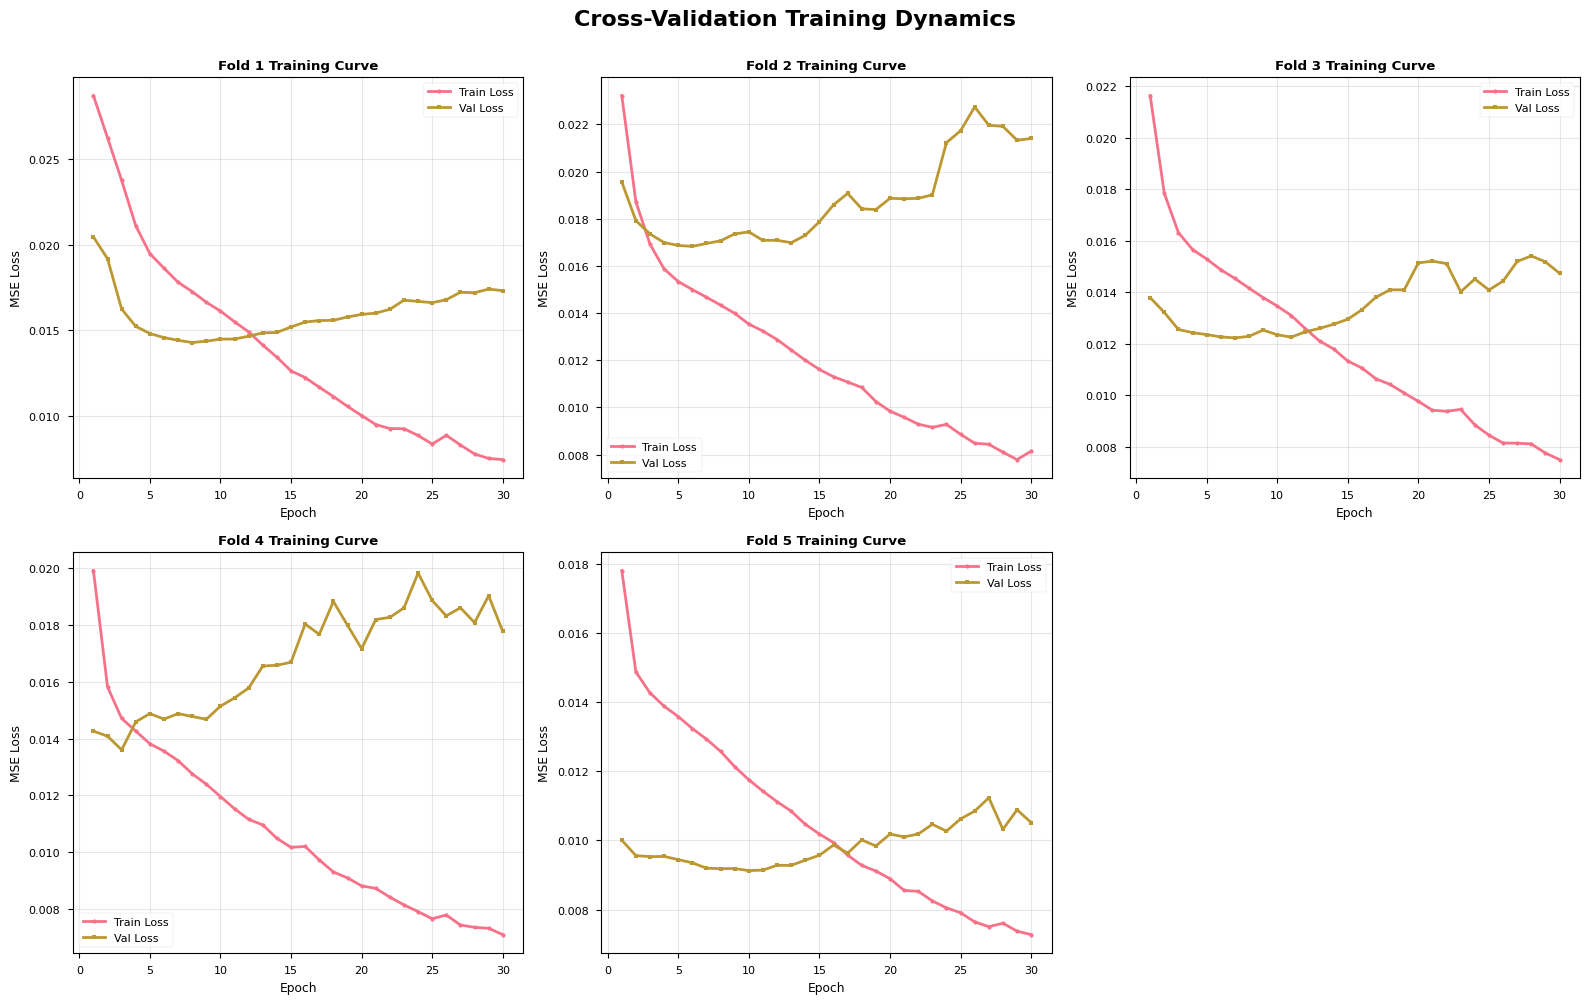

Figure 5: CV training curves saved


In [11]:
# Plot 5: Cross-validation training curves (all folds)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (hist, ax) in enumerate(zip(cv_histories, axes[:n_splits])):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax.plot(epochs, hist['train_loss'], label='Train Loss', linewidth=2, marker='o', markersize=3)
    if 'val_loss' in hist:
        ax.plot(epochs, hist['val_loss'], label='Val Loss', linewidth=2, marker='s', markersize=3)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'Fold {i+1} Training Curve', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide extra subplot
axes[-1].axis('off')

plt.suptitle('Cross-Validation Training Dynamics', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('fig5_cv_training_curves.png', bbox_inches='tight')
plt.show()

print('Figure 5: CV training curves saved')

C:\Users\31399\AppData\Local\Temp\ipykernel_21436\4273821745.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([cv_val_losses], labels=['CV Folds'], patch_artist=True,


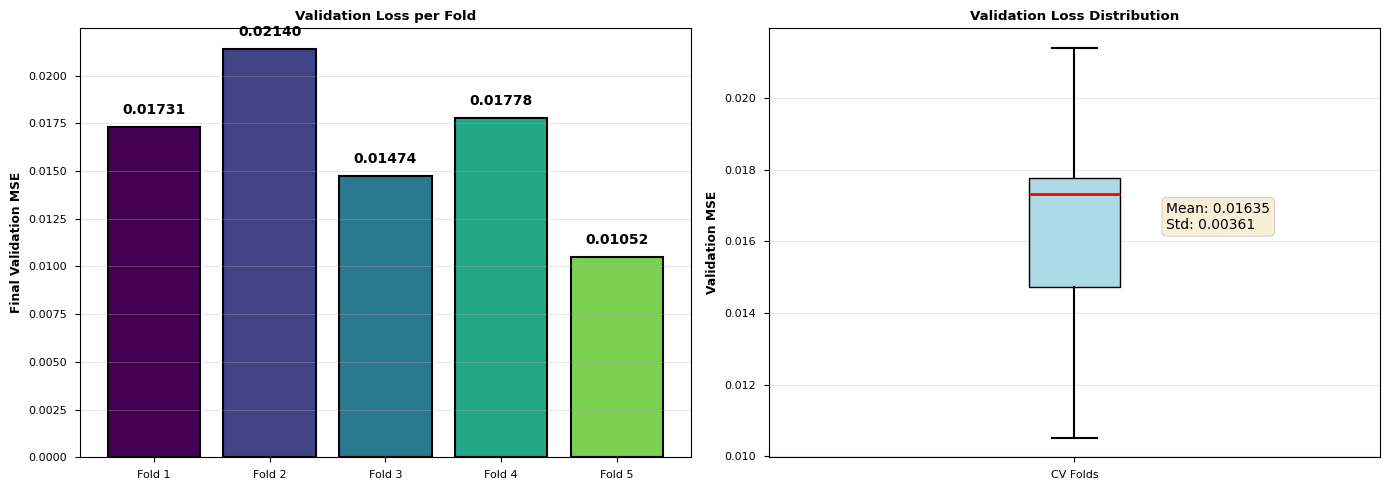

Figure 6: CV performance summary saved


In [12]:
# Plot 6: Final validation loss comparison across folds
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
fold_labels = [f'Fold {i+1}' for i in range(len(cv_val_losses))]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(cv_val_losses)))
bars = ax1.bar(fold_labels, cv_val_losses, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Final Validation MSE', fontweight='bold')
ax1.set_title('Validation Loss per Fold', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, cv_val_losses)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005, 
            f'{val:.5f}', ha='center', va='bottom', fontweight='bold')

# Box plot with statistics
ax2.boxplot([cv_val_losses], labels=['CV Folds'], patch_artist=True,
           boxprops=dict(facecolor='lightblue', edgecolor='black'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5))
ax2.set_ylabel('Validation MSE', fontweight='bold')
ax2.set_title('Validation Loss Distribution', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
mean_loss = np.mean(cv_val_losses)
std_loss = np.std(cv_val_losses)
ax2.text(1.15, mean_loss, f'Mean: {mean_loss:.5f}\nStd: {std_loss:.5f}', 
        fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig6_cv_performance_summary.png', bbox_inches='tight')
plt.show()

print('Figure 6: CV performance summary saved')

## 4. Prediction Performance Analysis

In [13]:
# Load best CV model and evaluate on test set
best_model = make_model()
if cv_best_checkpoint and os.path.isfile(cv_best_checkpoint):
    ckpt = torch.load(cv_best_checkpoint, map_location='cpu')
    best_model.load_state_dict(ckpt['model_state_dict'])
    print(f'Loaded best CV model from {cv_best_checkpoint}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
best_model = best_model.to(device)
best_model.eval()

# Generate predictions
with torch.no_grad():
    Xt = torch.tensor(X_test_ch, dtype=torch.float32).to(device)
    if Xt.ndim == 3 and Xt.shape[2] == 4:
        Xt = Xt.permute(0, 2, 1)
    preds = best_model(Xt)
    preds_np = preds.cpu().numpy()
    actuals_np = y_test

# Inverse transform predictions
preds_un = np.zeros_like(preds_np)
actuals_un = np.zeros_like(actuals_np)
for t in range(preds_np.shape[1]):
    try:
        preds_un[:, t] = processor.inverse_transform_predictions(preds_np[:, t])
        actuals_un[:, t] = processor.inverse_transform_predictions(actuals_np[:, t])
    except:
        preds_un[:, t] = preds_np[:, t]
        actuals_un[:, t] = actuals_np[:, t]

print(f'Test predictions generated: {preds_un.shape}')

Loaded best CV model from checkpoint/final_cv\fold_5\fold5_best.pt
Test predictions generated: (4943, 24)


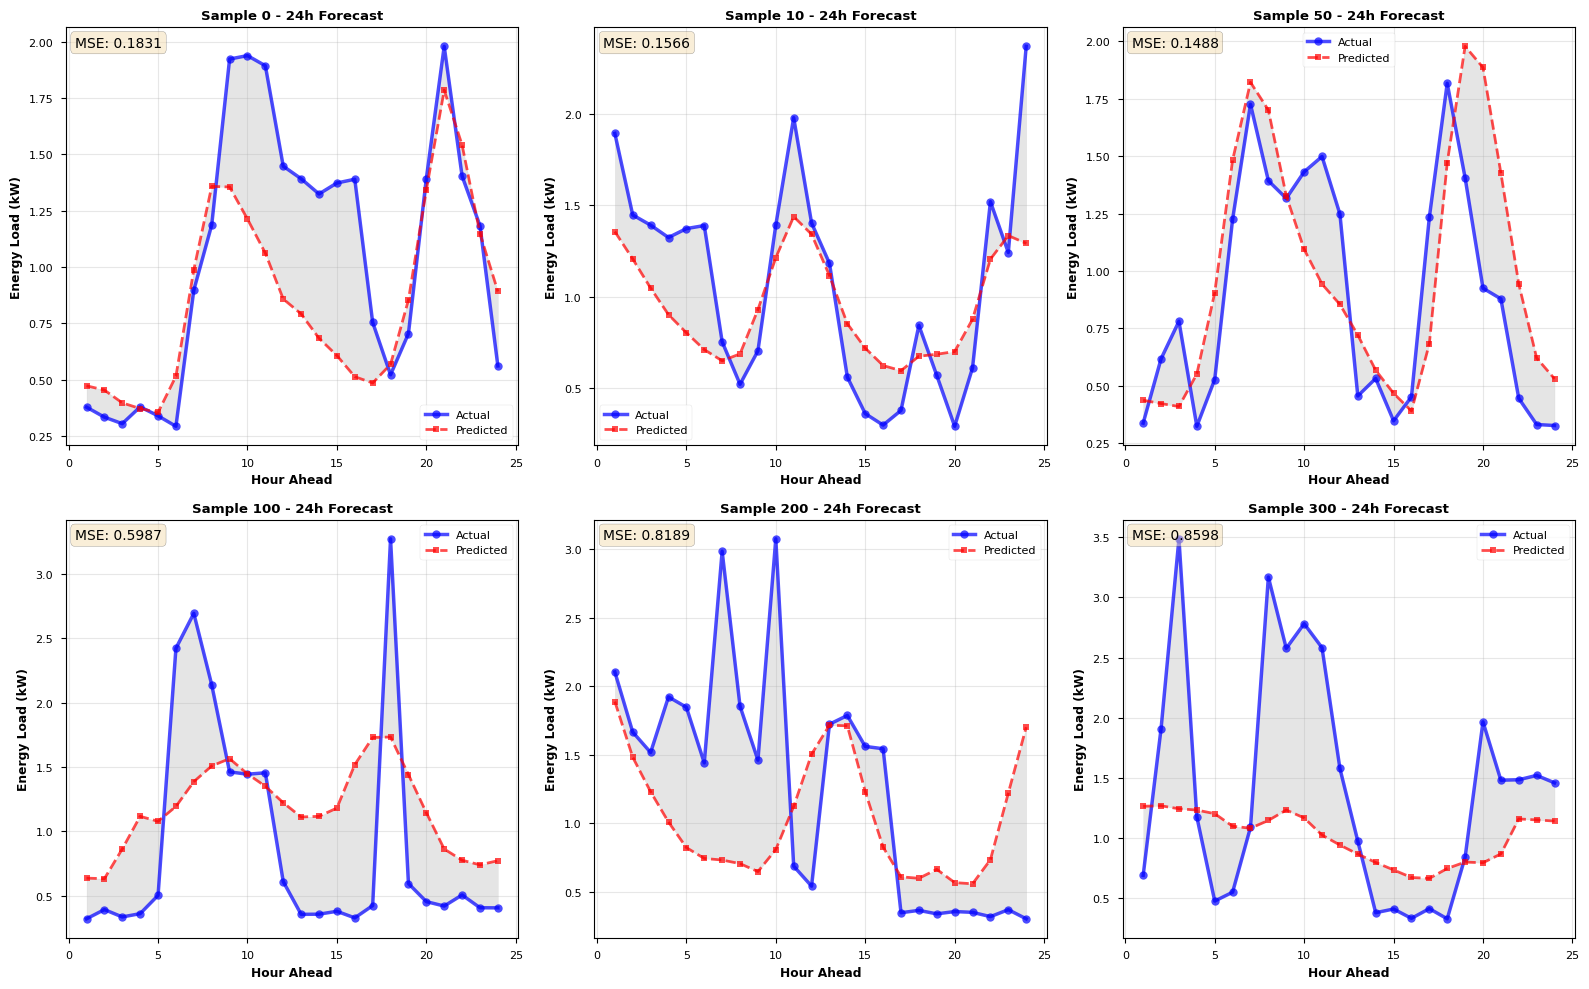

Figure 7: Sample predictions saved


In [14]:
# Plot 7: Sample predictions (multiple examples)
sample_indices = [0, 10, 50, 100, 200, 300]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (sample_idx, ax) in enumerate(zip(sample_indices, axes)):
    if sample_idx < len(preds_un):
        hours = range(1, 25)
        ax.plot(hours, actuals_un[sample_idx], 'o-', linewidth=2.5, markersize=6, 
               label='Actual', color='blue', alpha=0.7)
        ax.plot(hours, preds_un[sample_idx], 's--', linewidth=2, markersize=5, 
               label='Predicted', color='red', alpha=0.7)
        ax.fill_between(hours, actuals_un[sample_idx], preds_un[sample_idx], 
                       alpha=0.2, color='gray')
        ax.set_xlabel('Hour Ahead', fontweight='bold')
        ax.set_ylabel('Energy Load (kW)', fontweight='bold')
        ax.set_title(f'Sample {sample_idx} - 24h Forecast', fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        
        # Add MSE annotation
        mse = mean_squared_error(actuals_un[sample_idx], preds_un[sample_idx])
        ax.text(0.02, 0.98, f'MSE: {mse:.4f}', transform=ax.transAxes,
               verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig7_sample_predictions.png', bbox_inches='tight')
plt.show()

print('Figure 7: Sample predictions saved')

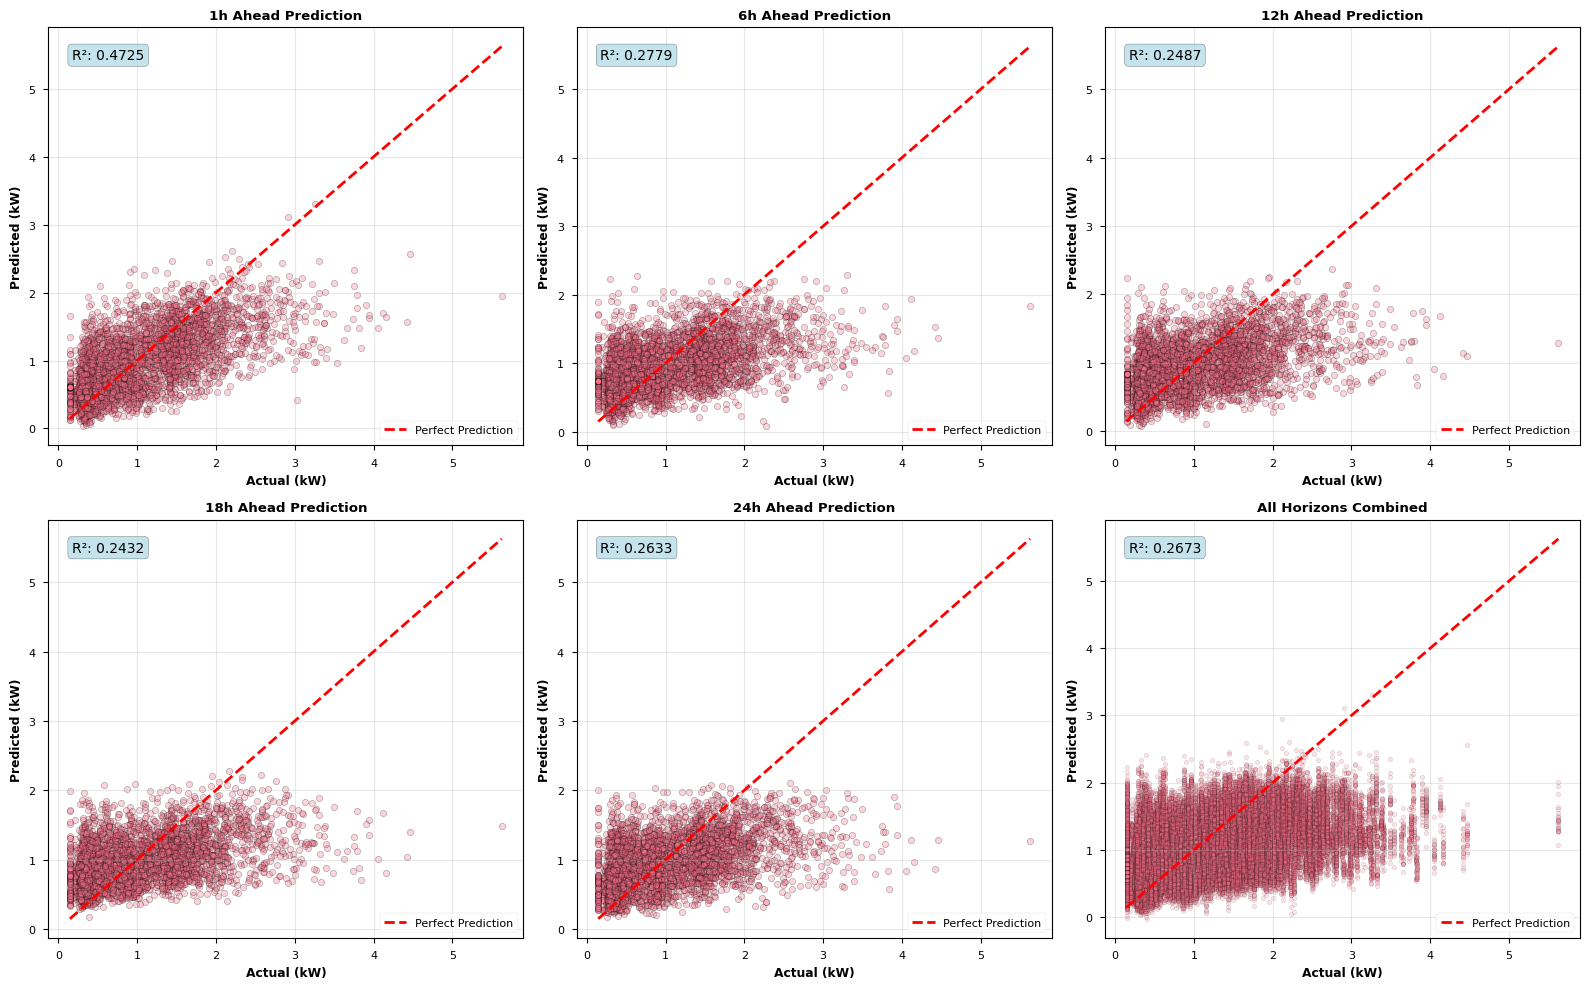

Figure 8: Prediction scatter plots saved


In [15]:
# Plot 8: Prediction vs Actual scatter plot (all horizons)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
horizons = [0, 5, 11, 17, 23]  # 1h, 6h, 12h, 18h, 24h ahead

for idx, (h, ax) in enumerate(zip(horizons, axes[:5])):
    ax.scatter(actuals_un[:, h], preds_un[:, h], alpha=0.3, s=20, edgecolors='k', linewidths=0.5)
    ax.plot([actuals_un[:, h].min(), actuals_un[:, h].max()], 
           [actuals_un[:, h].min(), actuals_un[:, h].max()], 
           'r--', linewidth=2, label='Perfect Prediction')
    ax.set_xlabel('Actual (kW)', fontweight='bold')
    ax.set_ylabel('Predicted (kW)', fontweight='bold')
    ax.set_title(f'{h+1}h Ahead Prediction', fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Add R² score
    r2 = r2_score(actuals_un[:, h], preds_un[:, h])
    ax.text(0.05, 0.95, f'R²: {r2:.4f}', transform=ax.transAxes,
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# Overall scatter for all horizons
ax = axes[-1]
ax.scatter(actuals_un.flatten(), preds_un.flatten(), alpha=0.2, s=10, edgecolors='k', linewidths=0.3)
ax.plot([actuals_un.min(), actuals_un.max()], 
       [actuals_un.min(), actuals_un.max()], 
       'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual (kW)', fontweight='bold')
ax.set_ylabel('Predicted (kW)', fontweight='bold')
ax.set_title('All Horizons Combined', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
r2_all = r2_score(actuals_un.flatten(), preds_un.flatten())
ax.text(0.05, 0.95, f'R²: {r2_all:.4f}', transform=ax.transAxes,
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig('fig8_prediction_scatter.png', bbox_inches='tight')
plt.show()

print('Figure 8: Prediction scatter plots saved')

## 5. Error Distribution and Statistical Analysis

In [16]:
# Calculate errors
errors = preds_un - actuals_un
abs_errors = np.abs(errors)
pct_errors = 100 * errors / (actuals_un + 1e-8)

# Compute metrics per horizon
horizons_range = range(1, 25)
mse_per_horizon = [mean_squared_error(actuals_un[:, h], preds_un[:, h]) for h in range(24)]
mae_per_horizon = [mean_absolute_error(actuals_un[:, h], preds_un[:, h]) for h in range(24)]
r2_per_horizon = [r2_score(actuals_un[:, h], preds_un[:, h]) for h in range(24)]

print('Error analysis complete')

Error analysis complete


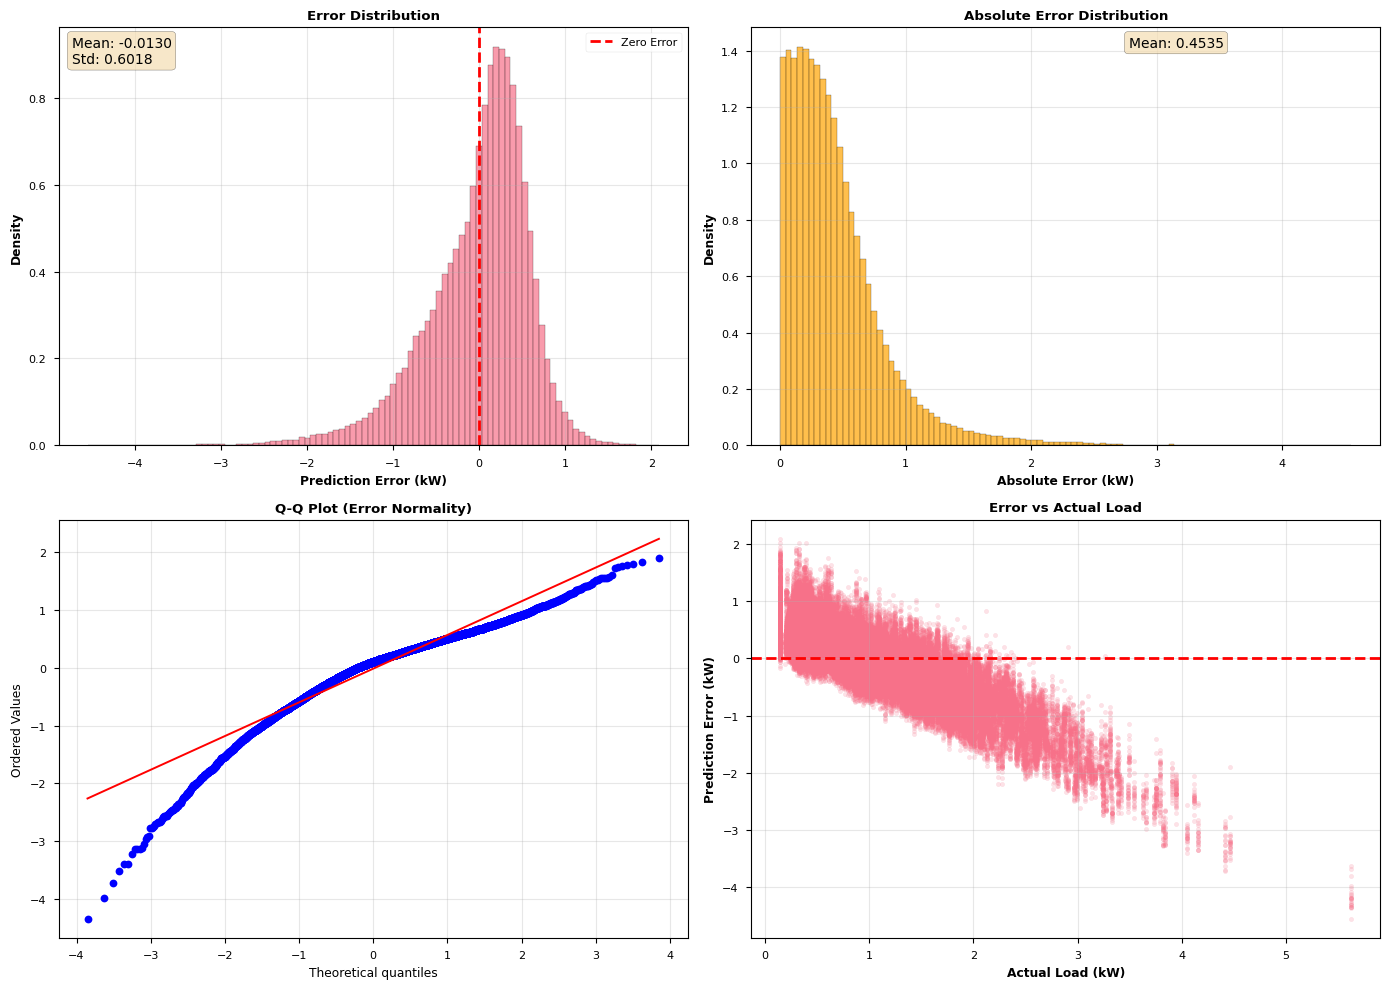

Figure 9: Error analysis saved


In [17]:
# Plot 9: Error distribution (histogram + statistics)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Absolute errors
ax = axes[0, 0]
ax.hist(errors.flatten(), bins=100, alpha=0.7, edgecolor='black', density=True)
ax.set_xlabel('Prediction Error (kW)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Error Distribution', fontweight='bold')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax.grid(True, alpha=0.3)
mean_err = np.mean(errors)
std_err = np.std(errors)
ax.text(0.02, 0.98, f'Mean: {mean_err:.4f}\nStd: {std_err:.4f}', 
       transform=ax.transAxes, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
ax.legend()

# Absolute errors
ax = axes[0, 1]
ax.hist(abs_errors.flatten(), bins=100, alpha=0.7, edgecolor='black', color='orange', density=True)
ax.set_xlabel('Absolute Error (kW)', fontweight='bold')
ax.set_ylabel('Density', fontweight='bold')
ax.set_title('Absolute Error Distribution', fontweight='bold')
ax.grid(True, alpha=0.3)
mean_abs_err = np.mean(abs_errors)
ax.text(0.6, 0.98, f'Mean: {mean_abs_err:.4f}', 
       transform=ax.transAxes, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Q-Q plot for normality check
ax = axes[1, 0]
stats.probplot(errors.flatten()[::10], dist="norm", plot=ax)  # Sample for speed
ax.set_title('Q-Q Plot (Error Normality)', fontweight='bold')
ax.grid(True, alpha=0.3)

# Error vs actual magnitude
ax = axes[1, 1]
ax.scatter(actuals_un.flatten(), errors.flatten(), alpha=0.2, s=10)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Actual Load (kW)', fontweight='bold')
ax.set_ylabel('Prediction Error (kW)', fontweight='bold')
ax.set_title('Error vs Actual Load', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig9_error_analysis.png', bbox_inches='tight')
plt.show()

print('Figure 9: Error analysis saved')

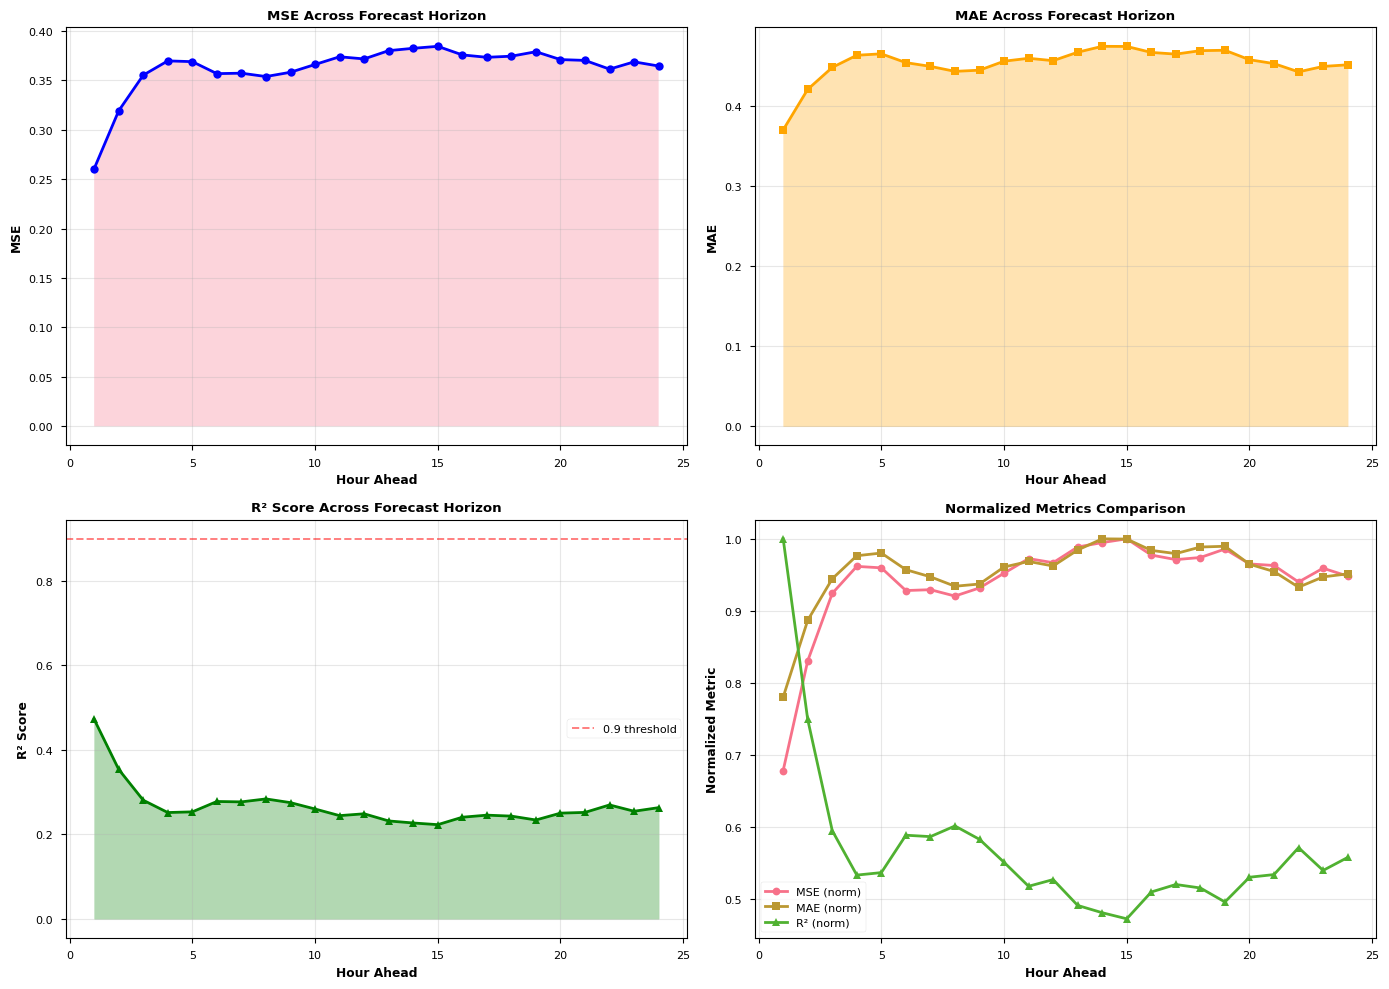

Figure 10: Horizon performance metrics saved


In [18]:
# Plot 10: Performance metrics across forecast horizon
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# MSE
ax = axes[0, 0]
ax.plot(horizons_range, mse_per_horizon, 'o-', linewidth=2, markersize=6, color='blue')
ax.set_xlabel('Hour Ahead', fontweight='bold')
ax.set_ylabel('MSE', fontweight='bold')
ax.set_title('MSE Across Forecast Horizon', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.fill_between(horizons_range, mse_per_horizon, alpha=0.3)

# MAE
ax = axes[0, 1]
ax.plot(horizons_range, mae_per_horizon, 's-', linewidth=2, markersize=6, color='orange')
ax.set_xlabel('Hour Ahead', fontweight='bold')
ax.set_ylabel('MAE', fontweight='bold')
ax.set_title('MAE Across Forecast Horizon', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.fill_between(horizons_range, mae_per_horizon, alpha=0.3, color='orange')

# R²
ax = axes[1, 0]
ax.plot(horizons_range, r2_per_horizon, '^-', linewidth=2, markersize=6, color='green')
ax.set_xlabel('Hour Ahead', fontweight='bold')
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('R² Score Across Forecast Horizon', fontweight='bold')
ax.grid(True, alpha=0.3)
ax.fill_between(horizons_range, r2_per_horizon, alpha=0.3, color='green')
ax.axhline(0.9, color='red', linestyle='--', alpha=0.5, label='0.9 threshold')
ax.legend()

# Combined metrics (normalized)
ax = axes[1, 1]
mse_norm = np.array(mse_per_horizon) / np.max(mse_per_horizon)
mae_norm = np.array(mae_per_horizon) / np.max(mae_per_horizon)
r2_norm = np.array(r2_per_horizon) / np.max(r2_per_horizon)
ax.plot(horizons_range, mse_norm, 'o-', label='MSE (norm)', linewidth=2)
ax.plot(horizons_range, mae_norm, 's-', label='MAE (norm)', linewidth=2)
ax.plot(horizons_range, r2_norm, '^-', label='R² (norm)', linewidth=2)
ax.set_xlabel('Hour Ahead', fontweight='bold')
ax.set_ylabel('Normalized Metric', fontweight='bold')
ax.set_title('Normalized Metrics Comparison', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig10_horizon_performance.png', bbox_inches='tight')
plt.show()

print('Figure 10: Horizon performance metrics saved')

## 6. Summary Statistics Table

In [19]:
# Create comprehensive performance summary
summary_stats = {
    'Metric': ['MSE', 'RMSE', 'MAE', 'R²', 'MAPE (%)', 'Max Error', 'Min Error'],
    'Overall': [
        mean_squared_error(actuals_un.flatten(), preds_un.flatten()),
        np.sqrt(mean_squared_error(actuals_un.flatten(), preds_un.flatten())),
        mean_absolute_error(actuals_un.flatten(), preds_un.flatten()),
        r2_score(actuals_un.flatten(), preds_un.flatten()),
        np.mean(np.abs(pct_errors)),
        np.max(errors),
        np.min(errors)
    ],
    '1h Ahead': [
        mse_per_horizon[0],
        np.sqrt(mse_per_horizon[0]),
        mae_per_horizon[0],
        r2_per_horizon[0],
        np.mean(np.abs(pct_errors[:, 0])),
        np.max(errors[:, 0]),
        np.min(errors[:, 0])
    ],
    '12h Ahead': [
        mse_per_horizon[11],
        np.sqrt(mse_per_horizon[11]),
        mae_per_horizon[11],
        r2_per_horizon[11],
        np.mean(np.abs(pct_errors[:, 11])),
        np.max(errors[:, 11]),
        np.min(errors[:, 11])
    ],
    '24h Ahead': [
        mse_per_horizon[23],
        np.sqrt(mse_per_horizon[23]),
        mae_per_horizon[23],
        r2_per_horizon[23],
        np.mean(np.abs(pct_errors[:, 23])),
        np.max(errors[:, 23]),
        np.min(errors[:, 23])
    ]
}

summary_df = pd.DataFrame(summary_stats)
print('\n' + '='*80)
print('PERFORMANCE SUMMARY STATISTICS')
print('='*80)
print(summary_df.to_string(index=False))
print('='*80)

# Save to CSV
summary_df.to_csv('performance_summary.csv', index=False)
print('\nSummary statistics saved to performance_summary.csv')


PERFORMANCE SUMMARY STATISTICS
   Metric   Overall  1h Ahead  12h Ahead  24h Ahead
      MSE  0.362344  0.260642   0.371659   0.364489
     RMSE  0.601950  0.510531   0.609639   0.603729
      MAE  0.453481  0.370534   0.457094   0.451907
       R²  0.267256  0.472472   0.248749   0.263271
 MAPE (%) 74.107839 55.011916  73.349211  72.596121
Max Error  2.089159  1.570525   2.089159   1.860857
Min Error -4.550779 -3.676624  -4.338284  -4.358022

Summary statistics saved to performance_summary.csv


## 7. Export Publication-Ready Figures

All figures have been saved in high resolution (300 DPI) suitable for academic publications:

- `fig1_feature_distribution.png` - Input feature distributions
- `fig2_temporal_patterns.png` - Temporal patterns across channels
- `fig3_correlation_heatmap.png` - Channel correlation matrix
- `fig4_model_architecture.png` - CNN architecture diagram
- `fig5_cv_training_curves.png` - Cross-validation training dynamics
- `fig6_cv_performance_summary.png` - CV performance summary
- `fig7_sample_predictions.png` - Sample prediction examples
- `fig8_prediction_scatter.png` - Prediction vs actual scatter plots
- `fig9_error_analysis.png` - Error distribution analysis
- `fig10_horizon_performance.png` - Performance across forecast horizon
- `performance_summary.csv` - Comprehensive statistics table